## Headers

In [1]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].astype('category').cat.codes

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [3]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [29]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Length: 569, dtype: int8

In [30]:
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio / (test_ratio + validation_ratio))

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (426, 30)
X_val shape: (85, 30)
X_test shape: (58, 30)


In [32]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_val shape:", X_val.shape)

X_train shape: (426, 30)
X_test shape: (58, 30)
X_val shape: (85, 30)


In [33]:
# Review the first few rows of the training data
print("First few rows of X_train:\n", X_train[:5])
print("First few rows of y_train:\n", y_train[:5])
print("First few rows of x_test:\n", X_test[:5])
print("First few rows of y_test:\n", y_test[:5])


First few rows of X_train:
      radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
233    20.51     27.81      134.40  1319.0      0.09159       0.10740   
26     14.58     21.53       97.41   644.8      0.10540       0.18680   
293    11.85     17.46       75.54   432.7      0.08372       0.05642   
74     12.31     16.52       79.19   470.9      0.09172       0.06829   
568     7.76     24.54       47.92   181.0      0.05263       0.04362   

     concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
233     0.15540          0.08340     0.1448             0.05592  ...   24.470   
26      0.14250          0.08783     0.2252             0.06924  ...   17.620   
293     0.02688          0.02280     0.1875             0.05715  ...   13.060   
74      0.03372          0.02272     0.1720             0.05914  ...   14.110   
568     0.00000          0.00000     0.1587             0.05884  ...    9.456   

     texture3  perimeter3   area3  smoothness3

In [63]:

from sklearn.linear_model import LogisticRegression
# Create and train the LogisticRegression model
log_reg = LogisticRegression(max_iter=2691)
log_reg.fit(X_train, y_train)
print("Iteraciones reales usadas:", log_reg.n_iter_[0])

Iteraciones reales usadas: 2690


In [35]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)


RandomForestClassifier()

In [37]:
from sklearn.svm import SVC

# Create and train the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


SVC(kernel='linear')

In [38]:
# Predict using the RandomForestClassifier
y_pred_lr = log_reg.predict(X_test)

# Evaluate the RandomForestClassifier
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix (Logistic Regressiont):\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))

Accuracy (Logistic Regression): 0.9655172413793104
Confusion Matrix (Logistic Regressiont):
 [[34  1]
 [ 1 22]]
Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        35
           1       0.96      0.96      0.96        23

    accuracy                           0.97        58
   macro avg       0.96      0.96      0.96        58
weighted avg       0.97      0.97      0.97        58



In [39]:
# Predict using the RandomForestClassifier with validation set
y_pred_rf = rf_clf.predict(X_test)
# Evaluate the RandomForestClassifier
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix (Random Forest):\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 1.0
Confusion Matrix (Random Forest):
 [[35  0]
 [ 0 23]]
Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        23

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



In [40]:
# Predict using the SVM model
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix (SVM):\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report (SVM):\n", classification_report(y_test, y_pred_svm))

Accuracy (SVM): 0.9827586206896551
Confusion Matrix (SVM):
 [[35  0]
 [ 1 22]]
Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.96      0.98        23

    accuracy                           0.98        58
   macro avg       0.99      0.98      0.98        58
weighted avg       0.98      0.98      0.98        58



In [41]:
# predict using the DecisionTreeClassifier
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9482758620689655
Confusion Matrix:
 [[33  2]
 [ 1 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        35
           1       0.92      0.96      0.94        23

    accuracy                           0.95        58
   macro avg       0.94      0.95      0.95        58
weighted avg       0.95      0.95      0.95        58



In [45]:
# Number of classes
num_classes = len(y.unique())
print("Number of classes:", num_classes)

# Initialize confusion matrix
manual_cm = [[0] * num_classes for _ in range(num_classes)]

print('-------', manual_cm)
print('-------y.unique()', y.unique())


# Populate the confusion matrix
for true_label, pred_label in zip(y_test, y_pred):
    # Increment the count in the confusion matrix
    manual_cm[true_label][pred_label] += 1

# Print the confusion matrix
print("Manually computed confusion matrix:")
for row in manual_cm:
    print(row)

Number of classes: 2
------- [[0, 0], [0, 0]]
-------y.unique() [1 0]
Manually computed confusion matrix:
[33, 2]
[1, 22]


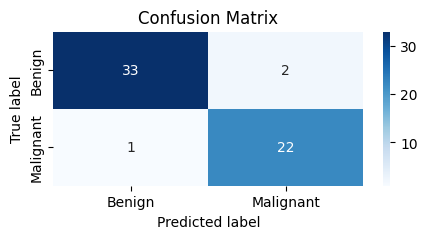

In [47]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()